<a href="https://colab.research.google.com/github/yuya0426/Kaggle_Heart_Disease/blob/main/notebooks/02_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# 1. API接続設定
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 2. フォルダ作成 (srcフォルダをColab上に用意)
os.makedirs('src', exist_ok=True)
os.makedirs('data', exist_ok=True)

# 3. データダウンロード（既にzipがある場合はスキップされる）
!kaggle competitions download -c playground-series-s6e2
!unzip -o playground-series-s6e2.zip -d data/

  0% 0.00/10.2M [00:00<?, ?B/s]
100% 10.2M/10.2M [00:00<00:00, 764MB/s]
Archive:  playground-series-s6e2.zip
  inflating: data/sample_submission.csv  
  inflating: data/test.csv           
  inflating: data/train.csv          


In [2]:
%%writefile src/config.py
class Config:
    # パス設定
    TRAIN_PATH = 'data/train.csv'
    TEST_PATH = 'data/test.csv'
    SUB_PATH = 'data/sample_submission.csv'

    # ターゲットと共通シード
    TARGET = 'Heart Disease Num'
    SEED = 42

    # 交差検証の設定
    N_FOLDS = 5

    # モデルパラメータ (まずは標準的な設定)
    XGB_PARAMS = {
        'n_estimators': 1000, # 多めに設定し、Early Stoppingで止める
        'learning_rate': 0.05,
        'random_state': SEED,
        'tree_method': 'hist',
        'early_stopping_rounds': 50
    }

Writing src/config.py


In [3]:
%%writefile src/utils.py
import pandas as pd
import numpy as np

def preprocess_data(df):
    # 1. ターゲットの数値化 (Absence=0, Presence=1)
    if 'Heart Disease' in df.columns:
        df['Heart Disease Num'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

    # 2. 【仮説1】HR Reserve（心拍予備能）の作成
    # 理論上の最大心拍数 (220 - Age) との差分を計算
    df['HR_Reserve'] = (220 - df['Age']) - df['Max HR']

    # 3. 【仮説2】ST-Slope Interaction
    # 信号の歪みと回復力の掛け合わせ
    df['ST_Slope_Interaction'] = df['ST depression'] * df['Slope of ST']

    return df

def get_features(df):
    # 学習に使用する列（idや元のターゲットを除外）
    drop_cols = ['id', 'Heart Disease', 'Heart Disease Num']
    return [c for c in df.columns if c not in drop_cols]

Writing src/utils.py


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from src.config import Config
from src.utils import preprocess_data, get_features

# 1. データの読み込みと前処理
train_df = pd.read_csv(Config.TRAIN_PATH)
train_df = preprocess_data(train_df)
features = get_features(train_df)

X = train_df[features]
y = train_df[Config.TARGET]

# 2. 交差検証の準備
skf = StratifiedKFold(n_splits=Config.N_FOLDS, shuffle=True, random_state=Config.SEED)
cv_scores = []
models = []

print(f"Starting {Config.N_FOLDS}-fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # モデルの訓練
    model = xgb.XGBClassifier(**Config.XGB_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # 予測とスコア計算
    preds = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, preds)
    cv_scores.append(score)
    models.append(model)

    print(f"Fold {fold+1} AUC: {score:.5f}")

print(f"\nMean CV AUC: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})")

Starting 5-fold Cross-Validation...

Fold 1 AUC: 0.95545
Fold 2 AUC: 0.95447
Fold 3 AUC: 0.95527
Fold 4 AUC: 0.95478
Fold 5 AUC: 0.95565

Mean CV AUC: 0.95512 (+/- 0.00044)


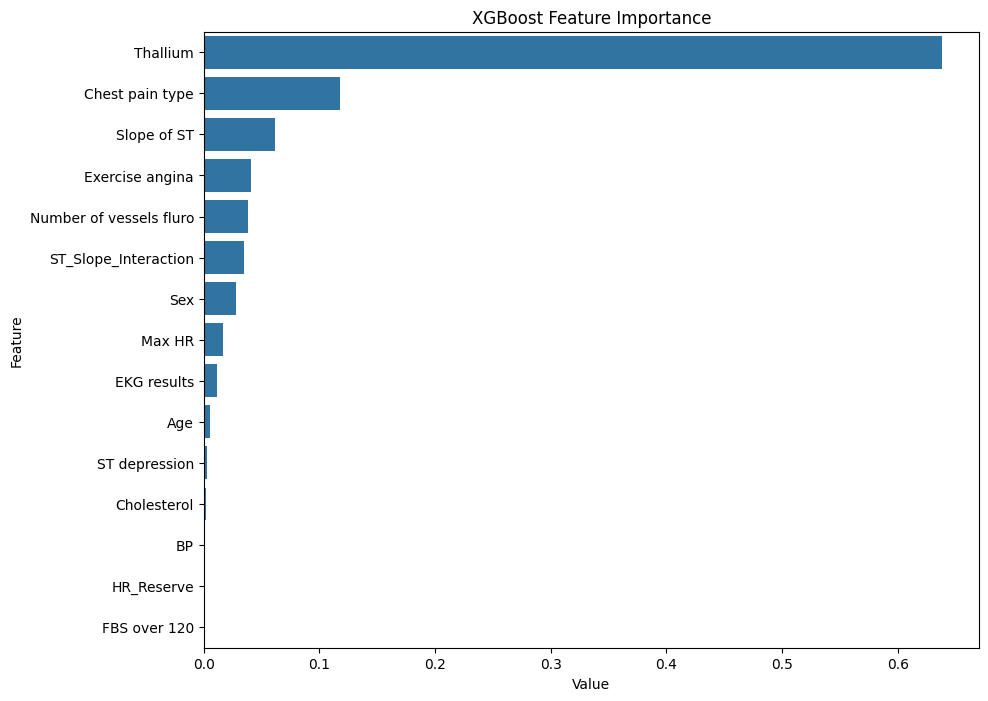

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 最後のフォールドのモデルから重要度を取得
importances = models[-1].feature_importances_
feature_imp = pd.DataFrame({'Value': importances, 'Feature': features})

plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('XGBoost Feature Importance')
plt.show()